# Restaurant Agent Example Without LLM

This notebook shows the restaurant example as code.

The flow is:

`START -> take_order -> send_to_kitchen -> cook_food -> serve_food -> END`

In [1]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

## State

State is like the order paper. It carries information from one restaurant step to the next step.

In [2]:
class RestaurantState(TypedDict, total=False):
    messages: Annotated[list, add_messages]
    order: str
    kitchen_status: str
    food_status: str
    served: bool

## Nodes

Each function below is one node. A node does one small job.

In [3]:
def take_order(state: RestaurantState) -> RestaurantState:
    order = state.get("order", "biryani")
    print("1. Taking order:", order)

    return {
        "order": order,
        "messages": [f"Waiter: Your order for {order} is noted."]
    }


def send_to_kitchen(state: RestaurantState) -> RestaurantState:
    order = state["order"]
    print("2. Sending order to kitchen:", order)

    return {
        "kitchen_status": "order sent to kitchen",
        "messages": [f"Kitchen received the order for {order}."]
    }


def cook_food(state: RestaurantState) -> RestaurantState:
    order = state["order"]
    print("3. Cooking food:", order)

    return {
        "food_status": f"{order} is ready",
        "messages": [f"Chef: The {order} is cooked and ready."]
    }


def serve_food(state: RestaurantState) -> RestaurantState:
    order = state["order"]
    print("4. Serving food:", order)

    return {
        "served": True,
        "messages": [f"Waiter: Here is your {order}. Enjoy your meal!"]
    }

## Build Graph

Edges connect nodes. They decide the order of work.

In [4]:
restaurant_builder = StateGraph(RestaurantState)

restaurant_builder.add_node("take_order", take_order)
restaurant_builder.add_node("send_to_kitchen", send_to_kitchen)
restaurant_builder.add_node("cook_food", cook_food)
restaurant_builder.add_node("serve_food", serve_food)

restaurant_builder.add_edge(START, "take_order")
restaurant_builder.add_edge("take_order", "send_to_kitchen")
restaurant_builder.add_edge("send_to_kitchen", "cook_food")
restaurant_builder.add_edge("cook_food", "serve_food")
restaurant_builder.add_edge("serve_food", END)

restaurant_graph = restaurant_builder.compile()

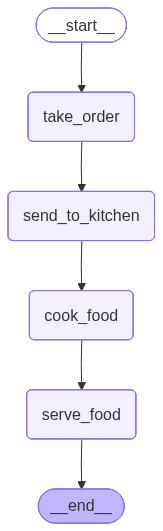

In [5]:
restaurant_graph

## Run Agent

The customer orders biryani. The state moves through every node.

In [6]:
restaurant_result = restaurant_graph.invoke({
    "order": "biryani",
    "messages": []
})

restaurant_result

1. Taking order: biryani
2. Sending order to kitchen: biryani
3. Cooking food: biryani
4. Serving food: biryani


/Users/maria/Documents/Agentic-AI/venv/lib/python3.12/site-packages/langsmith/client.py:653: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


{'messages': [HumanMessage(content='Waiter: Your order for biryani is noted.', additional_kwargs={}, response_metadata={}, id='0dbceada-1c94-4a4a-bfff-4ce280a5964b'),
  HumanMessage(content='Kitchen received the order for biryani.', additional_kwargs={}, response_metadata={}, id='2074fc6b-19d5-4934-883f-15801f97a3b7'),
  HumanMessage(content='Chef: The biryani is cooked and ready.', additional_kwargs={}, response_metadata={}, id='d4af13d0-ee32-4f7f-b576-0da5ea79c702'),
  HumanMessage(content='Waiter: Here is your biryani. Enjoy your meal!', additional_kwargs={}, response_metadata={}, id='c777cb98-e044-4d5a-9b91-f1819303f5dc')],
 'order': 'biryani',
 'kitchen_status': 'order sent to kitchen',
 'food_status': 'biryani is ready',
 'served': True}

Failed to multipart ingest runs: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=019f36e0-9a4e-7651-86e5-71390ce61439,id=019f36e0-9a4e-7651-86e5-71390ce61439; trace=019f36e0-9a4e-7651-86e5-71390ce61439,id=019f36e0-9a82-7d40-9a60-5b4d68108f5e; trace=019f36e0-9a4e-7651-86e5-71390ce61439,id=019f36e0-9a83-7051-9871-24848b33ada5; trace=019f36e0-9a4e-7651-86e5-71390ce61439,id=019f36e0-9acc-7711-aab0-194583ddf48c; trace=019f36e0-9a4e-7651-86e5-71390ce61439,id=019f36e0-9acc-7711-aab0-1952c5a6aaa6


In [7]:
for message in restaurant_result["messages"]:
    print(message.content)

Waiter: Your order for biryani is noted.
Kitchen received the order for biryani.
Chef: The biryani is cooked and ready.
Waiter: Here is your biryani. Enjoy your meal!
